In [ ]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, recall_score
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D projection)
import statsmodels.api as sm

# path and df setup
credit_path = Path("./credit_default.csv")
credit_df = pd.read_csv(credit_path)
X = credit_df.drop(columns=['default'])
y = credit_df['default']


workers_path = Path("./workers.csv")
workers_df   = pd.read_csv(workers_path)



## Q1. Bagging vs Boosting for Credit Default Prediction

Random forest vs XGboost

### Hyperparameter Tuning



For the Random Forest, the grid explored 144 combinations across n_estimators (50, 100, 150, 200) which were limited to save computational power. 

, max_depth (2, 3, 5, 10) , max_features (3, 5, 9),  and min_samples_leaf (1, 5, 10).

For XGBoost, 128 combinations were tested over n_estimators (50, 100, 150, 200) which were limited to save computational power (My computer started to freeze). 

 max_depth (2, 3, 4, 10), learning_rate (0.01, 0.03, 0.05, 0.1), and subsample (0.7 , 1.0).


#### Random Forest Findings

- Accuracy and AUC show diminishing returns as n_estimators increases, with the lower max_depth combinations even slightly decreasing as n_paramters grows.

- Deeper trees tend to achieve slightly higher CV accuracy and AUC than shallow ones  overall

- However, higher max_depth means that the tree  produces noticeably higher train accuracy than CV accuracy, i.e. they overfit to the sample rather than modelling patterns that can generalize. Shallower ones don't have that much of a gap, but they have some more bias.

- Increasing min_samples_leaf acts as an additional regulariser: larger values (e.g. 10) reduce overfitting but also reduce accuracy slightly, while min_samples_leaf = 1 allows the most flexible trees with the largest train-CV gap.

- The best RF models by log-loss and by accuracy/AUC: 

RANDOM FOREST -- Best Parameters (log-loss criterion):
   max_depth: 5
   max_features: 5
   min_samples_leaf: 1
   n_estimators: 150
   CV Log-Loss: 0.5059
   CV Accuracy: 0.7712
   CV AUC:      0.6870

the top five also show the max_features of 9 mostly, with max_paramters at 150/200 and depth of 5 and 10 (the largest depths)



#### XGBoost Findings

- The interaction between learning_rate and n_estimators is critical:

    - A small learning rate needs many more trees to converge; with only 50 trees the model underfits. A larger rate converges faster but can overshoot with 200 trees. 
    
    - The best combinations show a medium learning rate with larger n_estimators


- The Train vs CV gap is larger in XGboost, (with larger rates and n_estimators) because of the sequential characteristic of XGboost (sequential correction)

- Subsample values below 1.0 partially mitigate overfitting through stochastic sampling.


Best XGboost paramters:

(we can see how the relationship between learning rate and n_estimators hold)

XGBOOST -- Best Parameters (log-loss criterion):
   learning_rate: 0.03
   max_depth: 2
   n_estimators: 200
   subsample: 0.7
   CV Log-Loss: 0.5042
   CV Accuracy: 0.7707
   CV AUC:      0.6885

Top 5 XGB by Accuracy:
 n_est  max_depth   lr  subsample  CV Acc  CV AUC  CV NegLL
    50          3 0.10        1.0  0.7738  0.6871   -0.5050
   200          3 0.03        1.0  0.7732  0.6880   -0.5050
    50          4 0.05        0.7  0.7730  0.6872   -0.5054
   150          3 0.03        1.0  0.7728  0.6876   -0.5050
   100          3 0.05        1.0  0.7727  0.6870   -0.5052

In [ ]:

# 1.1 Random forest


rf_param_grid = {
    'n_estimators':     [50, 100, 150, 200],
    'max_depth':        [2, 3, 5, 10],         # limiting to 10 instead of None
    'max_features':     [3, 5, 9],             
    'min_samples_leaf': [1, 5, 10]
}

rf_base = RandomForestClassifier(criterion='log_loss', random_state=42, n_jobs=-1)

rf_grid = GridSearchCV(
    rf_base, rf_param_grid,
    cv=5,
    scoring=['neg_log_loss', 'accuracy', 'roc_auc'],
    refit='neg_log_loss',
    return_train_score=True,
    n_jobs=-1, verbose=1
)

rf_grid.fit(X, y)

rf_results  = pd.DataFrame(rf_grid.cv_results_)
best_rf_idx = rf_grid.best_index_

print(f"\n{'='*60}")
print("RANDOM FOREST -- Best Parameters (log-loss criterion):")
for k, v in rf_grid.best_params_.items():
    print(f"   {k}: {v}")
print(f"   CV Log-Loss: {-rf_grid.best_score_:.4f}")
print(f"   CV Accuracy: {rf_results.loc[best_rf_idx, 'mean_test_accuracy']:.4f}")
print(f"   CV AUC:      {rf_results.loc[best_rf_idx, 'mean_test_roc_auc']:.4f}")

# Top 5 by Accuracy and by AUC
_rf_cols_raw  = ['param_n_estimators', 'param_max_depth', 'param_max_features',
                 'param_min_samples_leaf', 'mean_test_accuracy', 'mean_test_roc_auc',
                 'mean_test_neg_log_loss']
_rf_cols_nice = ['n_est', 'max_depth', 'max_feat', 'min_leaf', 'CV Acc', 'CV AUC', 'CV NegLL']

rf_top_acc = rf_results.nlargest(5, 'mean_test_accuracy')[_rf_cols_raw].reset_index(drop=True)
rf_top_acc.columns = _rf_cols_nice
rf_top_auc = rf_results.nlargest(5, 'mean_test_roc_auc')[_rf_cols_raw].reset_index(drop=True)
rf_top_auc.columns = _rf_cols_nice

print(f"\nTop 5 RF by Accuracy:\n{rf_top_acc.round(4).to_string(index=False)}")
print(f"\nTop 5 RF by AUC:\n{rf_top_auc.round(4).to_string(index=False)}")

Fitting 5 folds for each of 144 candidates, totalling 720 fits

RANDOM FOREST -- Best Parameters (log-loss criterion):
   max_depth: 5
   max_features: 5
   min_samples_leaf: 1
   n_estimators: 150
   CV Log-Loss: 0.5059
   CV Accuracy: 0.7712
   CV AUC:      0.6870

Top 5 RF by Accuracy:
 n_est  max_depth  max_feat  min_leaf  CV Acc  CV AUC  CV NegLL
   150          5         9         5  0.7732  0.6864   -0.5059
   200          5         9         5  0.7732  0.6860   -0.5060
   150         10         9         5  0.7732  0.6808   -0.5088
    50         10         3         5  0.7728  0.6809   -0.5073
   200          5         9        10  0.7727  0.6855   -0.5062

Top 5 RF by AUC:
 n_est  max_depth  max_feat  min_leaf  CV Acc  CV AUC  CV NegLL
   200          5         3         5  0.7707  0.6888   -0.5064
   200          5         3         1  0.7710  0.6887   -0.5062
   150          5         3         1  0.7702  0.6877   -0.5066
   150          5         3         5  0.7692  0.687

In [ ]:

# 1.2 XGBOOST


xgb_param_grid = {
    'n_estimators':  [50, 100, 150, 200],
    'max_depth':     [2, 3, 4, 10],       # same here, limiting to 10 instead of None due to computer limitations
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample':     [0.7, 1.0]
}

xgb_base = XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1, verbosity=0)

xgb_grid = GridSearchCV(
    xgb_base, xgb_param_grid,
    cv=5,
    scoring=['neg_log_loss', 'accuracy', 'roc_auc'],
    refit='neg_log_loss',
    return_train_score=True,
    n_jobs=-1, verbose=1
)
xgb_grid.fit(X, y)

xgb_results  = pd.DataFrame(xgb_grid.cv_results_)
best_xgb_idx = xgb_grid.best_index_

print(f"\n{'='*60}")
print("XGBOOST -- Best Parameters (log-loss criterion):")
for k, v in xgb_grid.best_params_.items():
    print(f"   {k}: {v}")
print(f"   CV Log-Loss: {-xgb_grid.best_score_:.4f}")
print(f"   CV Accuracy: {xgb_results.loc[best_xgb_idx, 'mean_test_accuracy']:.4f}")
print(f"   CV AUC:      {xgb_results.loc[best_xgb_idx, 'mean_test_roc_auc']:.4f}")

_xgb_cols_raw  = ['param_n_estimators', 'param_max_depth', 'param_learning_rate',
                  'param_subsample', 'mean_test_accuracy', 'mean_test_roc_auc',
                  'mean_test_neg_log_loss']
                  
_xgb_cols_nice = ['n_est', 'max_depth', 'lr', 'subsample', 'CV Acc', 'CV AUC', 'CV NegLL']

xgb_top_acc = xgb_results.nlargest(5, 'mean_test_accuracy')[_xgb_cols_raw].reset_index(drop=True)
xgb_top_acc.columns = _xgb_cols_nice
xgb_top_auc = xgb_results.nlargest(5, 'mean_test_roc_auc')[_xgb_cols_raw].reset_index(drop=True)
xgb_top_auc.columns = _xgb_cols_nice

print(f"\nTop 5 XGB by Accuracy:\n{xgb_top_acc.round(4).to_string(index=False)}")
print(f"\nTop 5 XGB by AUC:\n{xgb_top_auc.round(4).to_string(index=False)}")

Fitting 5 folds for each of 128 candidates, totalling 640 fits

XGBOOST -- Best Parameters (log-loss criterion):
   learning_rate: 0.03
   max_depth: 2
   n_estimators: 200
   subsample: 0.7
   CV Log-Loss: 0.5042
   CV Accuracy: 0.7707
   CV AUC:      0.6885

Top 5 XGB by Accuracy:
 n_est  max_depth   lr  subsample  CV Acc  CV AUC  CV NegLL
    50          3 0.10        1.0  0.7738  0.6871   -0.5050
   200          3 0.03        1.0  0.7732  0.6880   -0.5050
    50          4 0.05        0.7  0.7730  0.6872   -0.5054
   150          3 0.03        1.0  0.7728  0.6876   -0.5050
   100          3 0.05        1.0  0.7727  0.6870   -0.5052

Top 5 XGB by AUC:
 n_est  max_depth   lr  subsample  CV Acc  CV AUC  CV NegLL
    50          3 0.10        0.7  0.7710  0.6888   -0.5042
   200          2 0.03        0.7  0.7707  0.6885   -0.5042
    50          2 0.10        0.7  0.7695  0.6883   -0.5043
   100          3 0.03        0.7  0.7722  0.6882   -0.5049
   150          2 0.03        0.7  0.

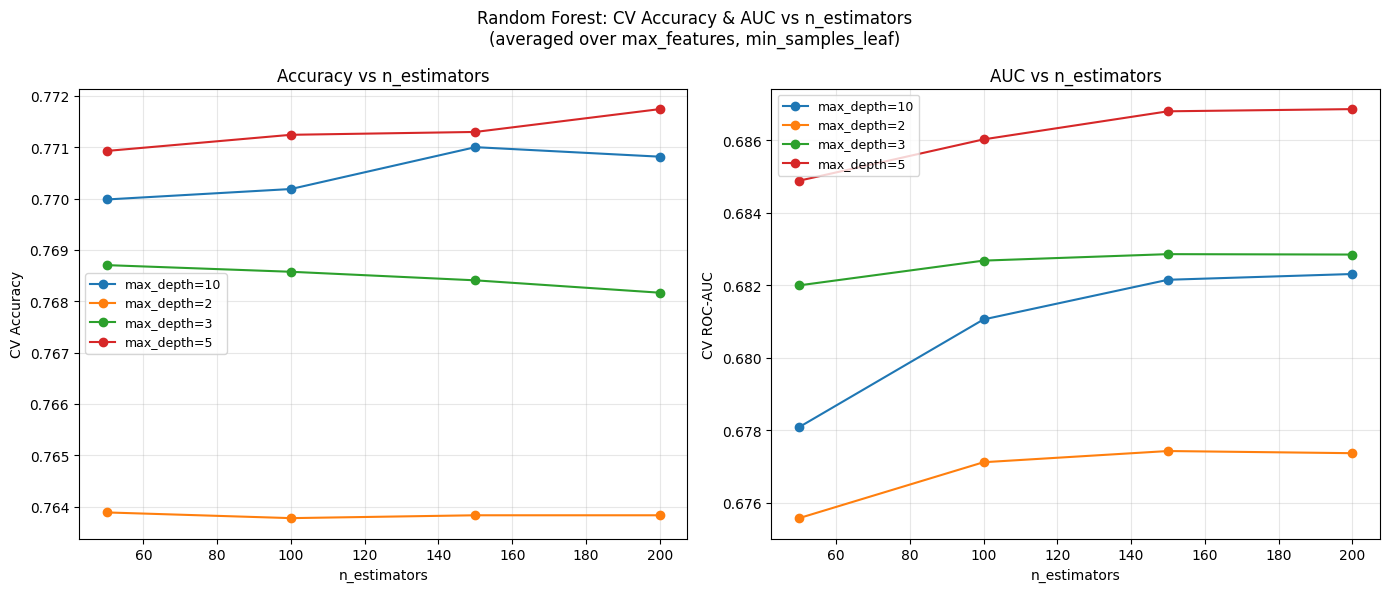

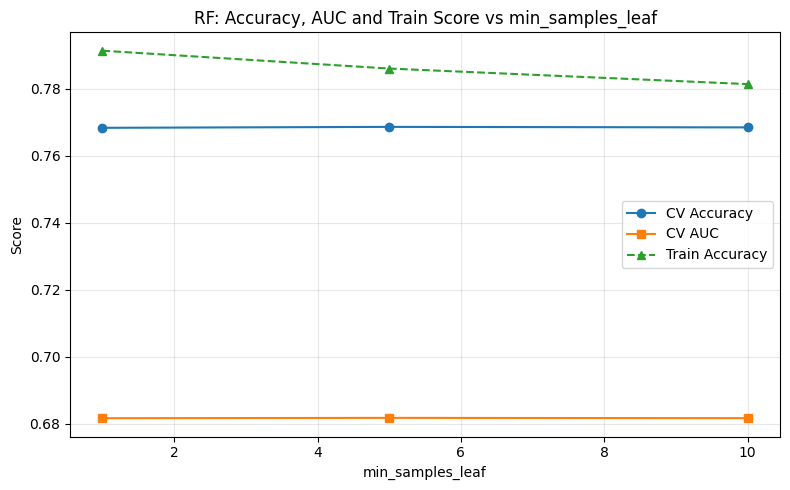

In [ ]:
# Random Forest plots


# Here I had to convert None to to strings so groupby work like it shoudl
rf_plot = rf_results.copy()
rf_plot['param_max_depth'] = rf_plot['param_max_depth'].astype(str)

rf_by_depth = rf_plot.groupby(
    ['param_max_depth', 'param_n_estimators'], dropna=False
).agg(
    cv_acc   =('mean_test_accuracy',  'mean'),
    cv_auc   =('mean_test_roc_auc',   'mean'),
    train_acc=('mean_train_accuracy', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Random Forest: CV Accuracy & AUC vs n_estimators\n(averaged over max_features, min_samples_leaf)', fontsize=12)

for depth, grp in rf_by_depth.groupby('param_max_depth'):
    grp = grp.sort_values('param_n_estimators')
    axes[0].plot(grp['param_n_estimators'], grp['cv_acc'], marker='o', label=f'max_depth={depth}')
    axes[1].plot(grp['param_n_estimators'], grp['cv_auc'], marker='o', label=f'max_depth={depth}')

for ax, ylabel, title in zip(
    axes,
    ['CV Accuracy', 'CV ROC-AUC'],
    ['Accuracy vs n_estimators', 'AUC vs n_estimators']
):
    ax.set_xlabel('n_estimators')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#  min_samples_leaf (averaged over all other params)
rf_by_leaf = rf_plot.groupby('param_min_samples_leaf').agg(
    cv_acc   =('mean_test_accuracy',  'mean'),
    cv_auc   =('mean_test_roc_auc',   'mean'),
    train_acc=('mean_train_accuracy', 'mean')
).reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rf_by_leaf['param_min_samples_leaf'], rf_by_leaf['cv_acc'],    marker='o', label='CV Accuracy')
ax.plot(rf_by_leaf['param_min_samples_leaf'], rf_by_leaf['cv_auc'],    marker='s', label='CV AUC')
ax.plot(rf_by_leaf['param_min_samples_leaf'], rf_by_leaf['train_acc'], marker='^', linestyle='--', label='Train Accuracy')
ax.set_xlabel('min_samples_leaf')
ax.set_ylabel('Score')
ax.set_title('RF: Accuracy, AUC and Train Score vs min_samples_leaf')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

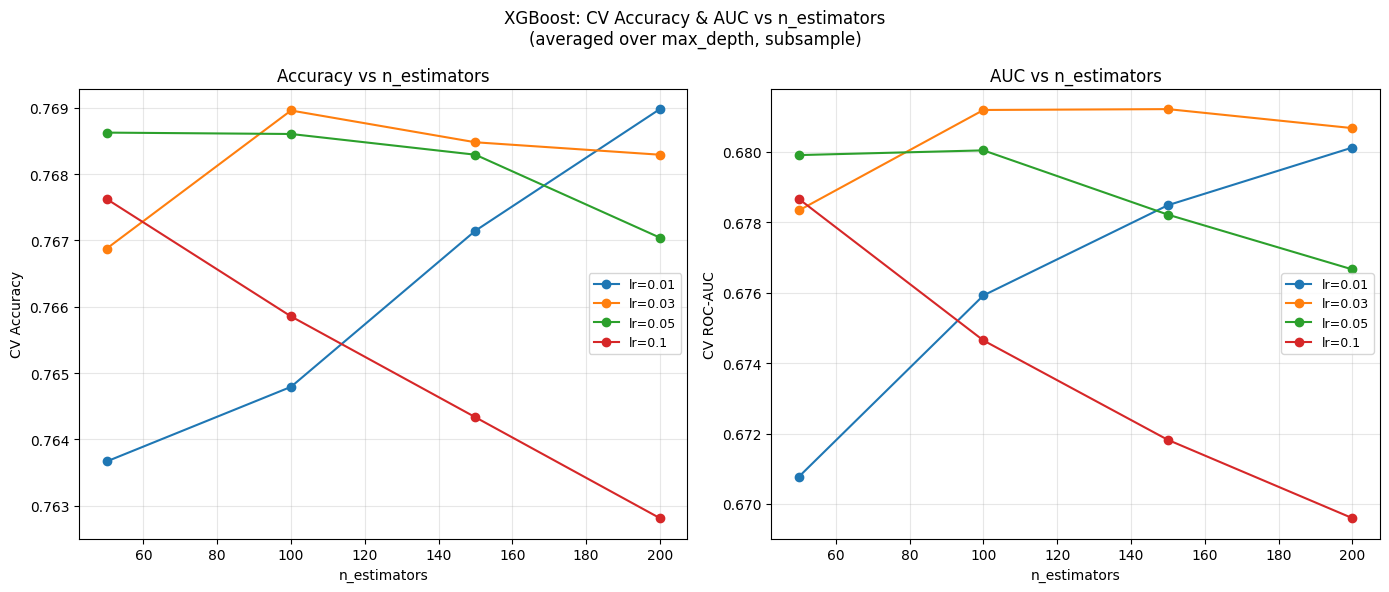

In [17]:
# XGboost plots


xgb_by_lr = xgb_results.groupby(
    ['param_learning_rate', 'param_n_estimators']
).agg(
    cv_acc   =('mean_test_accuracy',  'mean'),
    cv_auc   =('mean_test_roc_auc',   'mean'),
    train_acc=('mean_train_accuracy', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('XGBoost: CV Accuracy & AUC vs n_estimators\n(averaged over max_depth, subsample)', fontsize=12)

for lr, grp in xgb_by_lr.groupby('param_learning_rate'):
    grp = grp.sort_values('param_n_estimators')
    axes[0].plot(grp['param_n_estimators'], grp['cv_acc'], marker='o', label=f'lr={lr}')
    axes[1].plot(grp['param_n_estimators'], grp['cv_auc'], marker='o', label=f'lr={lr}')

for ax, ylabel, title in zip(
    axes,
    ['CV Accuracy', 'CV ROC-AUC'],
    ['Accuracy vs n_estimators', 'AUC vs n_estimators']
):
    ax.set_xlabel('n_estimators')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

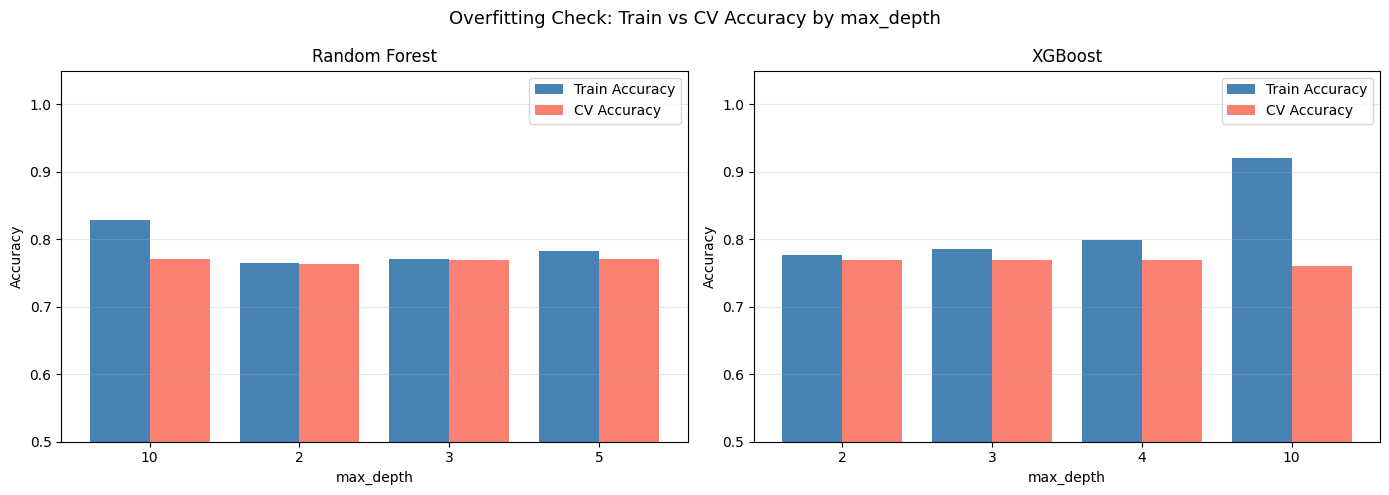

RF -- Train vs CV Accuracy gap by max_depth:
param_max_depth  train_acc  cv_acc    gap
             10     0.8279  0.7705 0.0574
              2     0.7641  0.7638 0.0003
              3     0.7701  0.7685 0.0016
              5     0.7832  0.7713 0.0119

XGB -- Train vs CV Accuracy gap by max_depth:
 param_max_depth  train_acc  cv_acc    gap
               2     0.7763  0.7686 0.0076
               3     0.7856  0.7695 0.0161
               4     0.7982  0.7686 0.0296
              10     0.9204  0.7608 0.1596


In [ ]:
# Train vs CV, avgd by max depth

rf_overfit = rf_plot.groupby('param_max_depth', dropna=False).agg(
    train_acc=('mean_train_accuracy', 'mean'),
    cv_acc   =('mean_test_accuracy',  'mean'),
).reset_index()
rf_overfit['gap'] = rf_overfit['train_acc'] - rf_overfit['cv_acc']

xgb_overfit = xgb_results.groupby('param_max_depth').agg(
    train_acc=('mean_train_accuracy', 'mean'),
    cv_acc   =('mean_test_accuracy',  'mean'),
).reset_index()
xgb_overfit['gap'] = xgb_overfit['train_acc'] - xgb_overfit['cv_acc']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Overfitting Check: Train vs CV Accuracy by max_depth', fontsize=13)

#Plots
for ax, df, title in zip(axes, [rf_overfit, xgb_overfit], ['Random Forest', 'XGBoost']):
    x = np.arange(len(df))
    ax.bar(x - 0.2, df['train_acc'], 0.4, label='Train Accuracy', color='steelblue')
    ax.bar(x + 0.2, df['cv_acc'],    0.4, label='CV Accuracy',    color='salmon')
    ax.set_xticks(x)
    ax.set_xticklabels(df['param_max_depth'].astype(str))
    ax.set_xlabel('max_depth')
    ax.set_ylabel('Accuracy')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0.5, 1.05)

plt.tight_layout()
plt.show()


# Print tables
print("RF -- Train vs CV Accuracy gap by max_depth:")
print(rf_overfit[['param_max_depth', 'train_acc', 'cv_acc', 'gap']].round(4).to_string(index=False))
print("\nXGB -- Train vs CV Accuracy gap by max_depth:")
print(xgb_overfit[['param_max_depth', 'train_acc', 'cv_acc', 'gap']].round(4).to_string(index=False))

### Model Comparison

#### Best Model Selection

The best model from an accuracy vs log loss perspective does not differ much for Random Forest in terms of log loss and accuracy values, however it shoes wifferences inmax features and min_leaf (5 vs 9,  and 1 vs 5 respectively)



### Best model for each: 


RANDOM FOREST -- Best Parameters (log-loss criterion):
   max_depth: 5
   max_features: 5
   min_samples_leaf: 1
   n_estimators: 150
   CV Log-Loss: 0.5059
   CV Accuracy: 0.7712
   CV AUC:      0.6870


RANDOM FOREST (accuracy):n_est  max_depth  max_feat  min_leaf  CV Acc  CV AUC  CV NegLL
   150          5         9         5  0.7732  0.6864   -0.5059
   


XGBOOST -- Best Parameters (log-loss criterion):
   learning_rate: 0.03
   max_depth: 2
   n_estimators: 200
   subsample: 0.7
   CV Log-Loss: 0.5042
   CV Accuracy: 0.7707
   CV AUC:      0.6885

XGB (accuracy):
 n_est  max_depth   lr  subsample  CV Acc  CV AUC  CV NegLL
    50          3 0.10        1.0  0.7738  0.6871   -0.5050






#### Feature Importance (Code below)


In a credit-risk context, we'd expect variables like past_default, num_late_payments_12m, debt_to_income, and credit_utilization to be strong predictors since they directly reflect financial stress. HAving the two models agree on the top predictors reflects signal consistency. Disagreement may come from different importance definitions or correlated features where each model picks a different proxy.

We can see how both RF and XGBoost show the same top 5 features, arranged differently. One key note is that XGboost concentrates a lot of feature importance on past_default, while RF has a more 'spread out' distb. Since the variable itself is likely to have high importance (From an economic/common sense perspective), it could simply be that it finds more value in that variable. 

HOWEVER

If importance is highly concentrated on a few features, the remaining predictors add little value and could just be creating noise

(Which seeems to be the case for the bottom features as seen in the print statements)

HOWEVER (again)

The concentration does look plausible for credit risk, since the most 'direct' metrics concentrate at the top. There are some features like age and home_owner that could seem like they should be more significant.


Top 5 Features -- Random Forest (best by log-loss):
num_late_payments_12m    0.1757
debt_to_income           0.1680
annual_income_gbp        0.1570
past_default             0.1256
credit_limit_gbp         0.1124

Top 5 Features -- XGBoost (best by log-loss):
past_default             0.2122
debt_to_income           0.1236
num_late_payments_12m    0.1161
annual_income_gbp        0.1006
credit_limit_gbp         0.0812


C:\Users\prida\AppData\Local\Temp\ipykernel_16396\1749685973.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_imp.head(5).values,  y=rf_imp.head(5).index,  ax=axes[0], palette='Blues_r')
C:\Users\prida\AppData\Local\Temp\ipykernel_16396\1749685973.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=xgb_imp.head(5).values, y=xgb_imp.head(5).index, ax=axes[1], palette='Oranges_r')


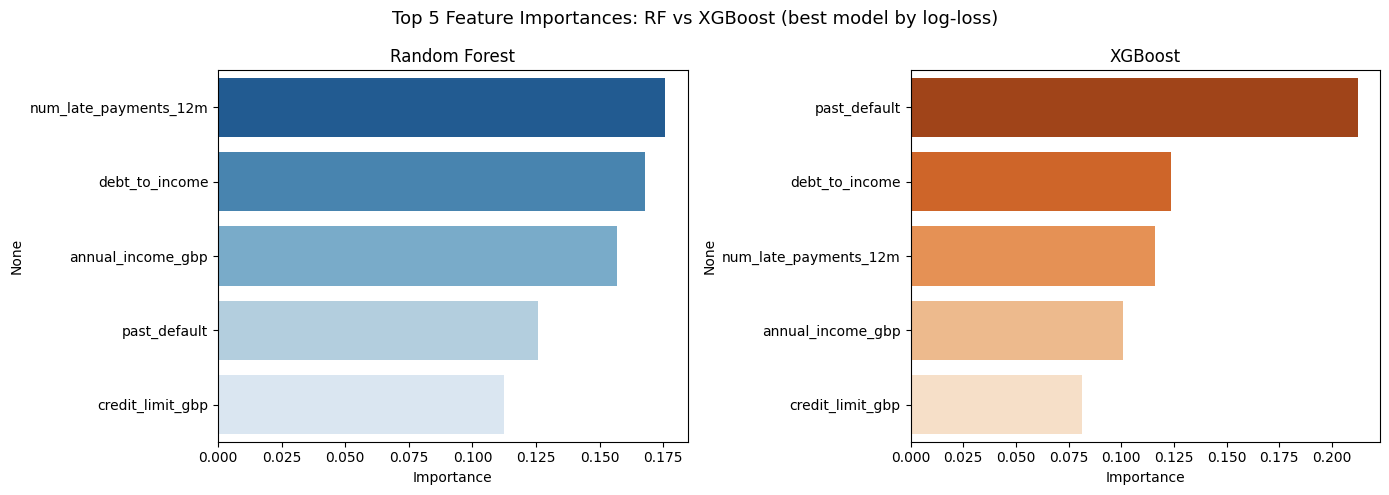


Full Feature Ranking Comparison:
                       RF Importance  RF Rank  XGB Importance  XGB Rank
num_late_payments_12m         0.1757        1          0.1161         3
debt_to_income                0.1680        2          0.1236         2
annual_income_gbp             0.1570        3          0.1006         4
past_default                  0.1256        4          0.2122         1
credit_limit_gbp              0.1124        5          0.0812         5
loan_amount_gbp               0.0855        6          0.0674         7
credit_utilization            0.0673        7          0.0485         8
age                           0.0341        8          0.0339        12
employment_years              0.0285        9          0.0364        10
home_owner                    0.0192       10          0.0710         6
num_credit_lines              0.0114       11          0.0349        11
inquiries_6m                  0.0097       12          0.0329        13
loan_term_months              

In [ ]:

# Feature importnace and plots

feature_names = X.columns.tolist()

rf_imp  = pd.Series(rf_grid.best_estimator_.feature_importances_,  index=feature_names).sort_values(ascending=False)
xgb_imp = pd.Series(xgb_grid.best_estimator_.feature_importances_, index=feature_names).sort_values(ascending=False)

print(f"\nTop 5 Features -- Random Forest (best by log-loss):\n{rf_imp.head(5).round(4).to_string()}")
print(f"\nTop 5 Features -- XGBoost (best by log-loss):\n{xgb_imp.head(5).round(4).to_string()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Top 5 Feature Importances: RF vs XGBoost (best model by log-loss)', fontsize=13)

sns.barplot(x=rf_imp.head(5).values,  y=rf_imp.head(5).index,  ax=axes[0], palette='Blues_r')
axes[0].set_title('Random Forest')
axes[0].set_xlabel('Importance')

sns.barplot(x=xgb_imp.head(5).values, y=xgb_imp.head(5).index, ax=axes[1], palette='Oranges_r')
axes[1].set_title('XGBoost')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

# Full ranking (print statement)
rank_df = pd.DataFrame({
    'RF Importance':  rf_imp.round(4),
    'RF Rank':        range(1, len(feature_names) + 1),
    'XGB Importance': xgb_imp.reindex(rf_imp.index).round(4),
    'XGB Rank':       xgb_imp.rank(ascending=False).astype(int).reindex(rf_imp.index)
})
print(f"\nFull Feature Ranking Comparison:\n{rank_df.to_string()}")

### Final Evaluation (see results print statement)

The best RF and XGB models (selected by log-loss) were evaluated over 30 repeated 80/20 train/test splits with different random seeds, giving a distribution of Accuracy and Recall that removes dependence on any single partition.

In a credit default setting, Recall (sensitivity) deserves higher priority than overall Accuracy. A false negative — predicting no default when the customer actually defaults — carries a much greater financial cost for the bank (unrecovered loans) than a false positive (declining a creditworthy customer). A model with higher recall catches more true defaulters even at the expense of some false alarms.


Following this logic, and given that the variability of both Accuracy and Recall are very similar across RF and XGB, the main difference lies in the recall number. 0.703 vs 0.1061 for RF and XGB respectively. 

Therefore, my final recommendation would be to stick with XGB in the context of credit risk




FINAL EVALUATION ,  30 Repeated Train/Test Splits (80/20):
   RF  Accuracy: 0.7718  ±  0.0111
   XGB Accuracy: 0.7706  ±  0.0107
   RF  Recall:   0.0703  ±  0.0158
   XGB Recall:   0.1061  ±  0.0182


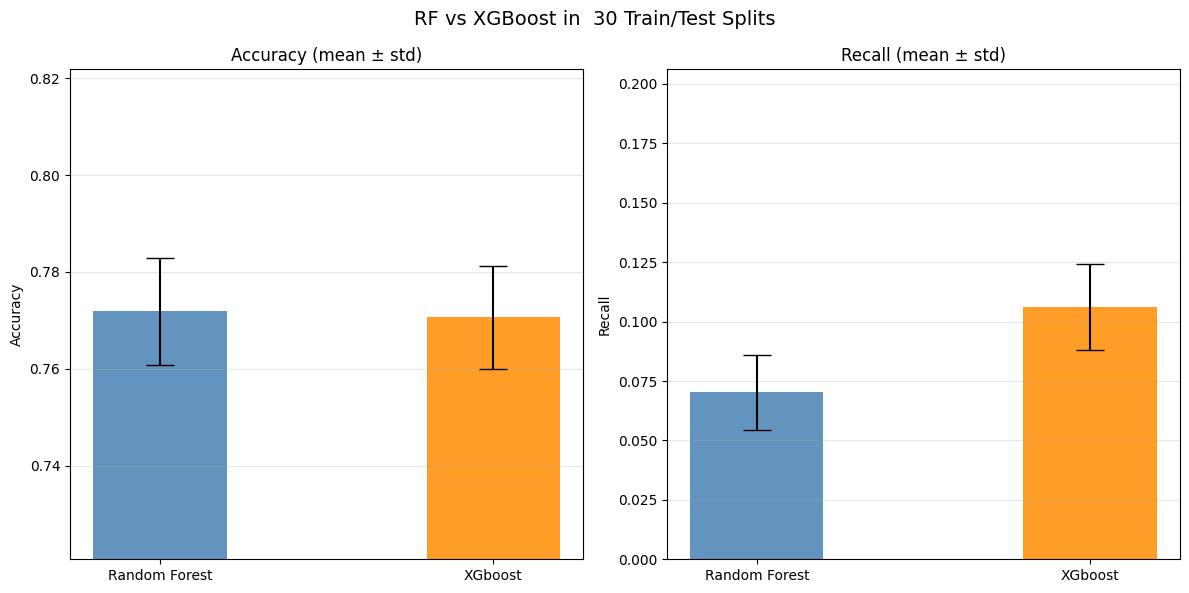

In [26]:

#  Final Evaluation,  30  Train/Test Splits 


best_rf_params  = dict(rf_grid.best_params_)
best_xgb_params = dict(xgb_grid.best_params_)

rf_accs, rf_recs, xgb_accs, xgb_recs = [], [], [], []

for seed in range(30):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

    rf_run = RandomForestClassifier(**best_rf_params, criterion='log_loss', random_state=42, n_jobs=-1)
    rf_run.fit(X_train, y_train)
    y_rf = rf_run.predict(X_test)
    rf_accs.append(accuracy_score(y_test, y_rf))
    rf_recs.append(recall_score(y_test, y_rf))

    xgb_run = XGBClassifier(**best_xgb_params, eval_metric='logloss', random_state=42, n_jobs=-1, verbosity=0)
    xgb_run.fit(X_train, y_train)
    y_xgb = xgb_run.predict(X_test)
    xgb_accs.append(accuracy_score(y_test, y_xgb))
    xgb_recs.append(recall_score(y_test, y_xgb))

#  Print table
print(f"\n{'='*60}")
print("FINAL EVALUATION ,  30 Repeated Train/Test Splits (80/20):")
print(f"   RF  Accuracy: {np.mean(rf_accs):.4f}  ±  {np.std(rf_accs):.4f}")
print(f"   XGB Accuracy: {np.mean(xgb_accs):.4f}  ±  {np.std(xgb_accs):.4f}")
print(f"   RF  Recall:   {np.mean(rf_recs):.4f}  ±  {np.std(rf_recs):.4f}")
print(f"   XGB Recall:   {np.mean(xgb_recs):.4f}  ±  {np.std(xgb_recs):.4f}")

models    = ['Random Forest', 'XGboost']
acc_means = [np.mean(rf_accs),  np.mean(xgb_accs)]
acc_stds  = [np.std(rf_accs),   np.std(xgb_accs)]
rec_means = [np.mean(rf_recs),  np.mean(xgb_recs)]
rec_stds  = [np.std(rf_recs),   np.std(xgb_recs)]

#Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('RF vs XGBoost in  30 Train/Test Splits', fontsize=14)

axes[0].bar(models, acc_means, yerr=acc_stds, capsize=10,
            color=['steelblue', 'darkorange'], alpha=0.85, width=0.4)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy (mean ± std)')
axes[0].set_ylim(max(0, min(acc_means) - 0.05), min(1, max(acc_means) + 0.05))
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(models, rec_means, yerr=rec_stds, capsize=10,
            color=['steelblue', 'darkorange'], alpha=0.85, width=0.4)
axes[1].set_ylabel('Recall')
axes[1].set_title('Recall (mean ± std)')
axes[1].set_ylim(max(0, min(rec_means) - 0.1), min(1, max(rec_means) + 0.1))
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Q3. PCA in Practice

Note: The explained variance by my model was not great (seen in plots), not sure if I went wrong somewhere in the code or the dataset is meant to be this way


### Data Inspection (see print table statement)

The dataset has 1,200 observations and 9 features. The summary statistics show substantial scale heterogeneity across variables. Some notable differences:

- Age has a mean of about 40.5 and a standard deviation of ~10.6
- Annual income (GBP) has a mean around 28,953 and a std of ~7,998 — several orders of magnitude larger than the hourly work variables
- The physical work variables (standing, lifting, manual intensity, repetitive motion) have means roughly between 1.7 and 5.2, with stds between 1.3 and 2.4
- Meetings hours per week has a higher std (~4.2) compared to the other time-based measures
- Chronic pain affects about 27.9% of workers (roughly 1 in 4)

The correlation matrix highlights two broad clusters, which are confirmed by the PCA loadings:

- Physical/manual cluster: standing hours, lifting hours, manual intensity score, and repetitive motion score are all positively correlated — workers who stand more also tend to lift more and report higher manual intensity
- Desk-work cluster: seated hours, computer hours, and meetings hours are positively associated; these are largely orthogonal to the physical cluster, since active and sedentary work don't really coexist in a given working day

Age is relatively independent of both clusters, while income shows a mild association with the desk-work group (higher-income workers tend to be office-based).

Workers dataset: 1200 observations, 9 features
Chronic pain prevalence: 27.92%

Summary statistics:
           age  annual_income_gbp  standing_hours_per_day  lifting_hours_per_day  manual_intensity_score  repetitive_motion_score  seated_hours_per_day  computer_hours_per_day  meetings_hours_per_week
count  1200.00            1200.00                 1200.00                1200.00                 1200.00                  1200.00               1200.00                 1200.00                  1200.00
mean     40.48           28953.08                    4.45                   1.72                    5.24                     4.92                  5.37                    4.13                     6.01
std      10.57            7997.72                    1.89                   1.32                    2.35                     2.17                  1.96                    1.82                     4.23
min      20.00           16000.00                    0.00                   0.00                

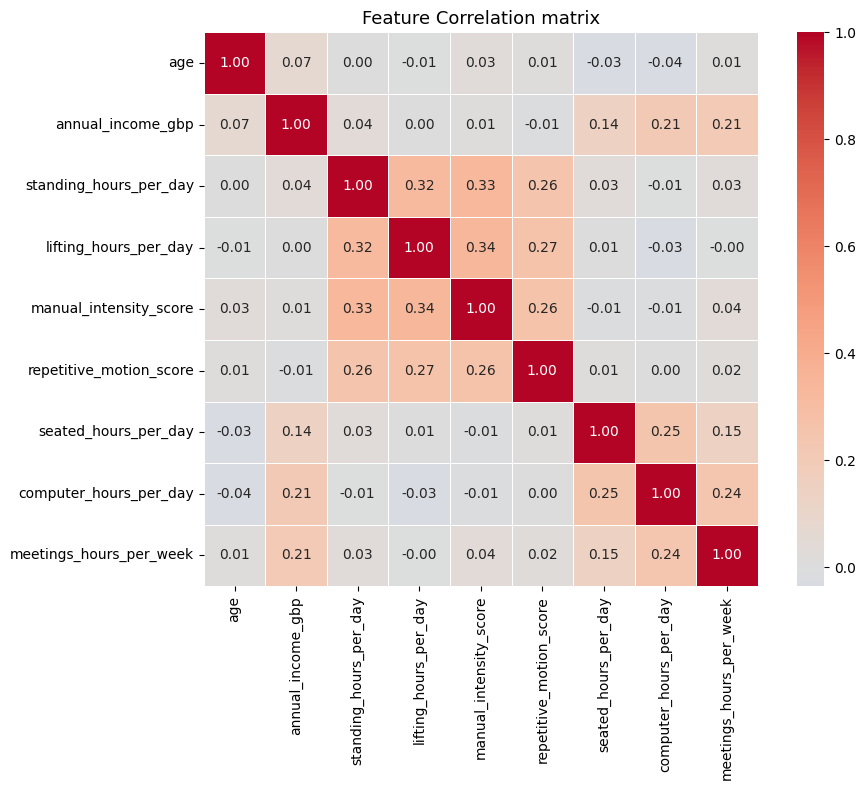

In [ ]:

#  Data Inspection

feat_cols = [
    'age', 'annual_income_gbp', 'standing_hours_per_day', 'lifting_hours_per_day',
    'manual_intensity_score', 'repetitive_motion_score',
    'seated_hours_per_day', 'computer_hours_per_day', 'meetings_hours_per_week'
]


X_w = workers_df[feat_cols]
y_w = workers_df['chronic_pain']

# prints
print(f"Workers dataset: {workers_df.shape[0]} observations, {len(feat_cols)} features")
print(f"Chronic pain prevalence: {y_w.mean():.2%}\n")
print("Summary statistics:")
print(X_w.describe().round(2).to_string())


# PLot
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(X_w.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix -- Workers Dataset', fontsize=13)
plt.tight_layout()
plt.show()

###  Preprocessing and Justification

Before running PCA, the features were standardised (zero mean, unit variance) using StandardScaler. 

Why?:

1. Scale differences: annual_income_gbp has a standard deviation several orders of magnitude larger than the hourly variables. Without standardisation, PCA would be dominated by income simply because of its larger numeric range, not because it's genuinely more variable in a meaningful sense.
2. PCA maximises variance: since PCA finds the directions of maximum variance, variables on larger scales would artificially dominate the first principal component. Standardisation puts all variables on equal footing so that PCA reflects the underlying covariance structure, not measurement units.

Mean-centering is performed automatically by StandardScaler and is also a  requirement for PCA (if not done the covariance calc would be biased by the mean).

In [ ]:

# Standarization
.
scaler  = StandardScaler()
X_w_std = scaler.fit_transform(X_w)

# Fit
pca    = PCA()
X_pca  = pca.fit_transform(X_w_std)

eigvals   = pca.explained_variance_
var_ratio = pca.explained_variance_ratio_
cum_var   = np.cumsum(var_ratio)
n_feat    = len(feat_cols)
pc_labels = [f'PC{i+1}' for i in range(n_feat)]

# Print table
print(f"\n{'='*60}")
print("PCA -- Variance Explained per Component:")
for i, (ev, vr, cv) in enumerate(zip(eigvals, var_ratio, cum_var)):
    print(f"  PC{i+1}: eigenvalue={ev:.3f}  |  var={vr:.2%}  |  cumulative={cv:.2%}")


PCA -- Variance Explained per Component:
  PC1: eigenvalue=1.898  |  var=21.07%  |  cumulative=21.07%
  PC2: eigenvalue=1.601  |  var=17.78%  |  cumulative=38.85%
  PC3: eigenvalue=1.042  |  var=11.57%  |  cumulative=50.42%
  PC4: eigenvalue=0.858  |  var=9.53%  |  cumulative=59.94%
  PC5: eigenvalue=0.807  |  var=8.96%  |  cumulative=68.90%
  PC6: eigenvalue=0.755  |  var=8.39%  |  cumulative=77.29%
  PC7: eigenvalue=0.715  |  var=7.94%  |  cumulative=85.23%
  PC8: eigenvalue=0.682  |  var=7.57%  |  cumulative=92.80%
  PC9: eigenvalue=0.648  |  var=7.20%  |  cumulative=100.00%


### Principal Components: Eigenvalues and Loadings

The eigenvalue table below summarises how much variance each component explains:

| PC | Eigenvalue | Variance | Cumulative |
|---|---|---|---|
| 1 | 1.898 | 21.1% | 21.1% |
| 2 | 1.601 | 17.8% | 38.9% |
| 3 | 1.042 | 11.6% | 50.4% |
| 4 | 0.858 | 9.5% | 59.9% |
| 5 | 0.807 | 9.0% | 68.9% |
| 6 | 0.755 | 8.4% | 77.3% |
| 7 | 0.715 | 7.9% | 85.2% |
| 8 | 0.682 | 7.6% | 92.8% |
| 9 | 0.648 | 7.2% | 100.0% |

The eigenvalues decrease gradually with no sharp elbow,  no single dominant latent factor drives the data, although 4 can be considered the 'drop'

#### Reading the Loadings

The correlation loadings are computed as:

$$\text{cor}(x_i, \text{PC}_j) = v_{ji} \times \sqrt{\lambda_j}$$


The full correlation loadings matrix for the first three PCs:

| Variable | PC1 | PC2 | PC3 |
|---|---|---|---|
| age | 0.031 | 0.003 | 0.915 |
| annual_income_gbp | 0.073 | 0.601 | 0.313 |
| standing_hours_per_day | 0.697 | -0.020 | -0.019 |
| lifting_hours_per_day | 0.703 | -0.100 | -0.054 |
| manual_intensity_score | 0.713 | -0.063 | 0.049 |
| repetitive_motion_score | 0.622 | -0.054 | -0.039 |
| seated_hours_per_day | 0.065 | 0.583 | -0.261 |
| computer_hours_per_day | 0.024 | 0.704 | -0.149 |
| meetings_hours_per_week | 0.103 | 0.622 | 0.100 |



#### Naming the Principal Components

PC1 — "Physical Labour Intensity"

The four dominant variables all measure the physical demands of a job: standing upright, carrying weight, exerting effort, and repetitive movement. They load strongly and positively, while every desk-work variable (seated_hours_per_day, computer_hours_per_day, meetings_hours_per_week, annual_income_gbp) has a near-zero loading on PC1 (all below 0.11). Workers who do more of one of these activities tend to do more of the others, forming a physical-work cluster that makes sense

PC2 — "Desk Work Intensity"

The four dominant variables (computer_hours_per_day, meetings_hours_per_week, annual_income_gbp, seated_hours_per_day) describe sedentary work. All four physical-work variables that drove PC1 load near-zero on PC2 (range: -0.10 to -0.02), which makes sense since you can't simultaneously lift heavy loads and sit at a computer for hours in the same job (mostly)

PC3 — "Seniority / Age"

A single variable dominates: age (0.92), the largest individual loading across all three PCs. Annual_income_gbp contributes modestly (0.31), reflecting the income premium that typically builds up over a career. All work-activity variables load near-zero on PC3 (range: -0.26 to 0.10). The fact that annual_income_gbp loads on both PC2 (0.60) and PC3 (0.31) makes sense since income relates to both job type and career stage, so its variance gets split across two components. PC3 captures career stage independently of whether someone is in a physical or desk-based role.

#### Confirmation from the Correlation Circle Plots

- PC1 vs PC2: The four physical-work arrows cluster in the positive-PC1 / near-zero-PC2 region; the four office-work arrows cluster in the near-zero-PC1 / positive-PC2 region. The two groups sit roughly at 90° to each other. Age lies near the origin, confirming it contributes almost nothing to either PC1 or PC2.

- PC1 vs PC3: Age projects strongly along PC3, while the physical-work arrows remain along PC1. The almost right angle between age and the physical variables confirms PC3 is independent of physical job demands.

- PC2 vs PC3: Age points along PC3, the office-work arrows point along PC2. Annual_income_gbp's arrow sits between the two axes, reflecting its split role across desk-work and seniority. Physical-work arrows are near the origin, confirming they contribute minimally to either PC2 or PC3.

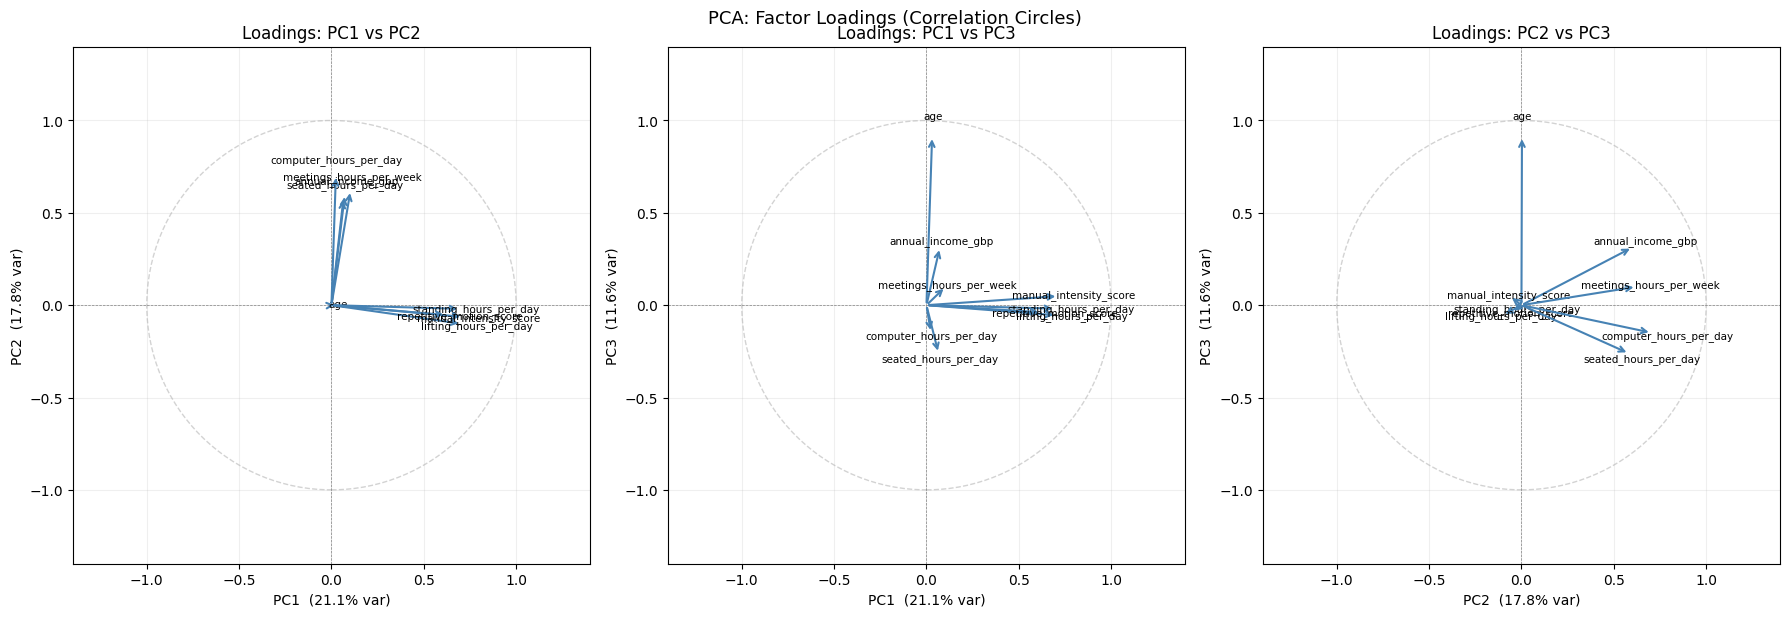

In [ ]:

#Factor Loadings Plots (Correlation Circles)


# Correlation loadings: cor(x_i, PC_j) = component[j,i] * sqrt(eigenvalue[j])

comp_loadings = pca.components_[:3]                         # shape (3, n_features)
corr_loadings = (comp_loadings.T * np.sqrt(eigvals[:3]))    # shape (n_features, 3)
loadings_df   = pd.DataFrame(corr_loadings, index=feat_cols, columns=['PC1', 'PC2', 'PC3'])


# MAde a function since it was nearly impossible to get right
def _plot_loading_circle(pc_x, pc_y, ax):
    idx_x = int(pc_x[2:]) - 1
    idx_y = int(pc_y[2:]) - 1
    for feat in feat_cols:
        lx = loadings_df.loc[feat, pc_x]
        ly = loadings_df.loc[feat, pc_y]
        ax.annotate('', xy=(lx, ly), xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.5))
        ax.text(lx * 1.12, ly * 1.12, feat, fontsize=7.5, ha='center', va='center')
    ax.axhline(0, color='grey', lw=0.5, ls='--')
    ax.axvline(0, color='grey', lw=0.5, ls='--')
    circle = plt.Circle((0, 0), 1, fill=False, color='lightgrey', ls='--')
    ax.add_patch(circle)
    ax.set_xlim(-1.4, 1.4)
    ax.set_ylim(-1.4, 1.4)
    ax.set_xlabel(f'{pc_x}  ({var_ratio[idx_x]:.1%} var)', fontsize=10)
    ax.set_ylabel(f'{pc_y}  ({var_ratio[idx_y]:.1%} var)', fontsize=10)
    ax.set_title(f'Loadings: {pc_x} vs {pc_y}')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)


# plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('PCA: Factor Loadings (Correlation Circles)', fontsize=13)
_plot_loading_circle('PC1', 'PC2', axes[0])
_plot_loading_circle('PC1', 'PC3', axes[1])
_plot_loading_circle('PC2', 'PC3', axes[2])
plt.tight_layout()
plt.show()

### 2D and 3D Projections

The 2D scatter plot of PC1 vs PC2 maps workers into a "job-type space" — workers in the upper-right are physically active and office-intensive, while those in the lower-left have low demands on both dimensions. The two chronic pain groups overlap substantially in this 2D projection, suggesting that job type alone (without age) doesn't cleanly separate pain cases.

Adding PC3 in the 3D projection brings in the age/seniority axis. Older workers may show a slight tendency toward chronic pain at any level of PC1 or PC2, providing some additional separation that the first two PCs couldn't capture.

(OVerall not much separation at least plot-wise)

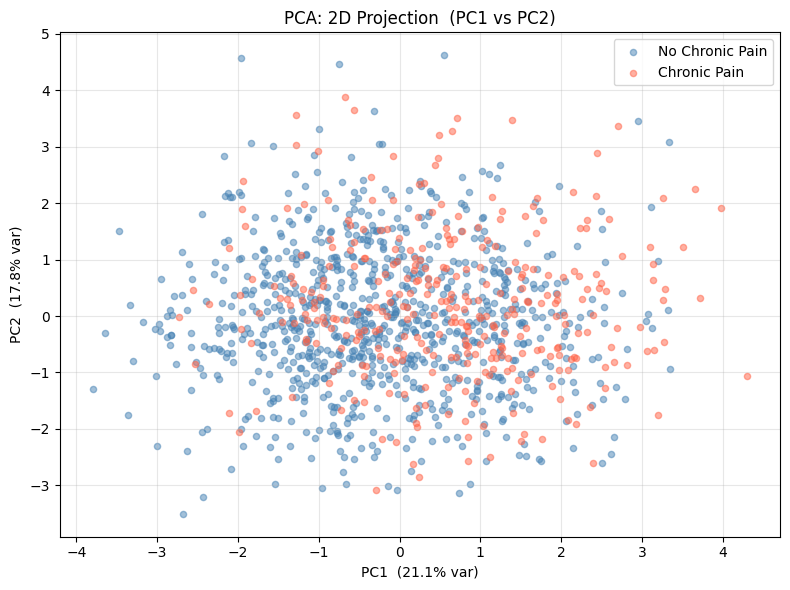

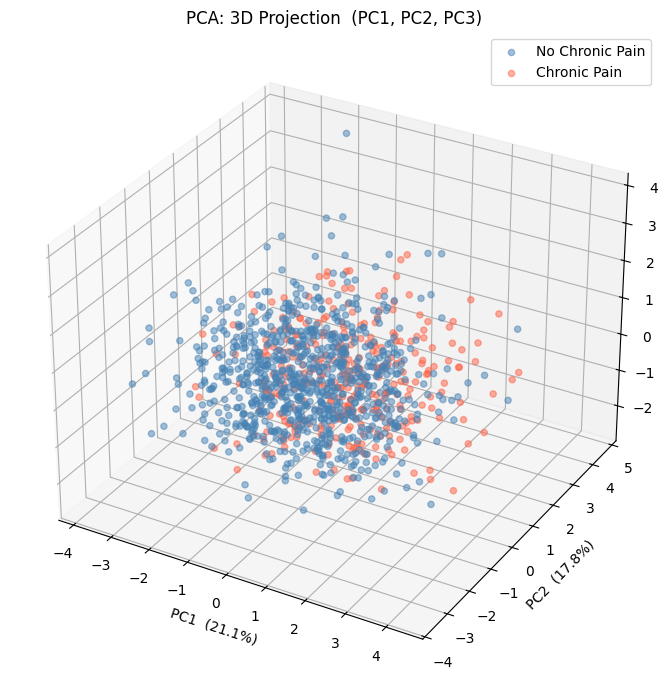

In [ ]:
# Projections

_pain_map = {0: ('steelblue', 'No Chronic Pain'), 1: ('tomato', 'Chronic Pain')}

fig, ax = plt.subplots(figsize=(8, 6))
for label, (color, name) in _pain_map.items():
    mask = y_w == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, alpha=0.5, s=20, label=name)
ax.set_xlabel(f'PC1  ({var_ratio[0]:.1%} var)')
ax.set_ylabel(f'PC2  ({var_ratio[1]:.1%} var)')
ax.set_title('PCA: 2D Projection  (PC1 vs PC2)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(10, 7))
ax3 = fig.add_subplot(111, projection='3d')
for label, (color, name) in _pain_map.items():
    mask = y_w == label
    ax3.scatter(X_pca[mask, 0], X_pca[mask, 1], X_pca[mask, 2],
                c=color, alpha=0.5, s=20, label=name)
ax3.set_xlabel(f'PC1  ({var_ratio[0]:.1%})')
ax3.set_ylabel(f'PC2  ({var_ratio[1]:.1%})')
ax3.set_zlabel(f'PC3  ({var_ratio[2]:.1%})')
ax3.set_title('PCA: 3D Projection  (PC1, PC2, PC3)')
ax3.legend()
plt.tight_layout()
plt.show()

### Dimensionality Reduction

Criteria Applied:

1. Kaiser : retain only components whose eigenvalue exceeds 1

2. Scree : plot eigenvalues in decreasing order and look for an "elbow" . Components before the elbow are retained.

3. Cumulative variance threshold: retain the minimum number of components needed to explain at least 80ish or 90ish % of total variance.

The actual variance breakdown is roughly: PC1 explains 21.1%, PC2 adds another 17.8% (cumulative 38.9%), PC3 adds 11.6% (cumulative 50.4%), and the remaining components each contribute between 7% and 10%. 

#### It takes 7 components to cross the 80% threshold and 8 to reach 90%.

The three criteria give divergent recommendations:

- Kaiser says to retain the three first components
- Scree plot doesnt show a 'big elbow', the sharpest would be the drop at pc4, cutting at 3
- the variance treshold requires almost all components (that would go against the point)


The most viable option would be to cut at 3, due to double kaiser/scree agreement. However it severely cuts off the total variance (roughly half), since the alternative pretty much does nothing in terms of reducing dimensaionality


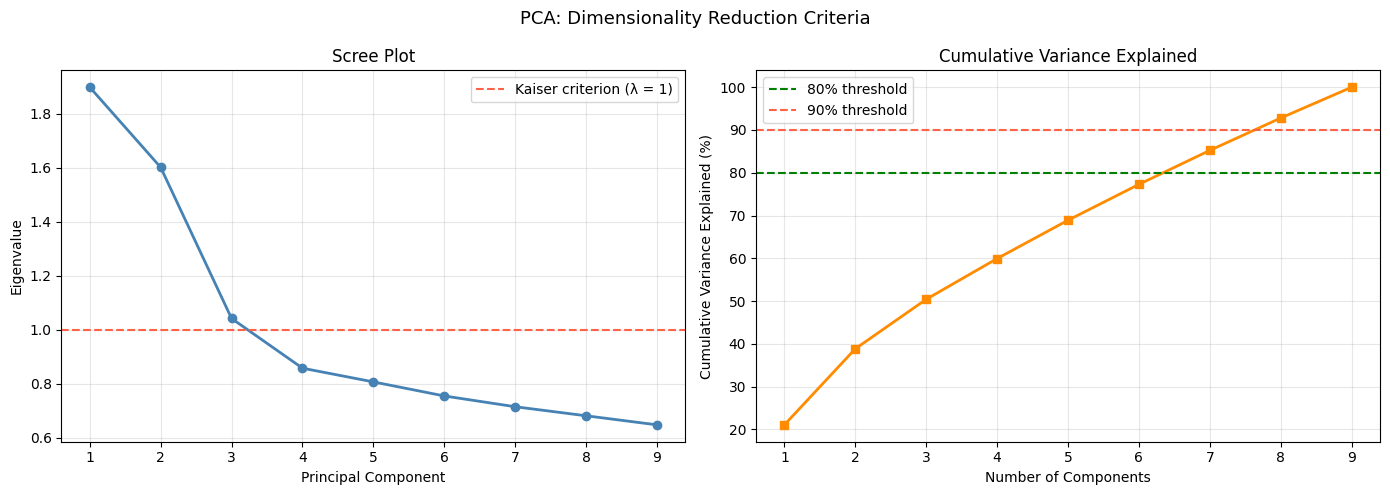


Kaiser criterion (λ > 1):  retain 3 component(s)
80% variance threshold:    retain 7 component(s)
90% variance threshold:    retain 8 component(s)


In [ ]:
# Criteria for reduction

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PCA: Dimensionality Reduction Criteria', fontsize=13)

# Scree plot
axes[0].plot(range(1, n_feat + 1), eigvals, marker='o', color='steelblue', lw=2)
axes[0].axhline(y=1, color='tomato', ls='--', lw=1.5, label='Kaiser criterion (lambda = 1)')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Eigenvalue')
axes[0].set_title('Scree Plot')
axes[0].set_xticks(range(1, n_feat + 1))
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Cumulative variance
axes[1].plot(range(1, n_feat + 1), cum_var * 100, marker='s', color='darkorange', lw=2)
axes[1].axhline(y=80, color='green',  ls='--', lw=1.5, label='80% threshold')
axes[1].axhline(y=90, color='tomato', ls='--', lw=1.5, label='90% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained (%)')
axes[1].set_title('Cumulative Variance Explained')
axes[1].set_xticks(range(1, n_feat + 1))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calcs
kaiser_n = int(np.sum(eigvals > 1))
pct80_n  = int(np.argmax(cum_var >= 0.80)) + 1
pct90_n  = int(np.argmax(cum_var >= 0.90)) + 1

# Prints
print(f"\nKaiser criterion (lambda > 1):  retain {kaiser_n} component(s)")
print(f"80% variance threshold:    retain {pct80_n} component(s)")
print(f"90% variance threshold:    retain {pct90_n} component(s)")

---

## Q3. Logistic Regression

### Data Inspection: chronic_pain and its Correlations

The target chronic_pain is binary, with a prevalence of 27.9% (335 out of 1,200 workers). The class imbalance is moderate and doesn't require resampling for logistic regression.

Correlation with original features

- lifting_hours_per_day is the most strongly correlated (~0.216)
- repetitive_motion_score follows (~0.185)
- standing_hours_per_day comes next (~0.167)
- manual_intensity_score (~0.154) and age (~0.093) are in the middle
- annual_income_gbp and computer_hours_per_day are the weakest correlates

Physical-work variables dominate, which is consistent with the PCA findings. Income and computer hours show the weakest linear relationship with chronic pain.

Correlation with the retained PCs:

- PC1 (Physical Labour) is by far the most predictive (~0.273)
- PC2 (Desk Work) and PC3 (Age/Seniority) show weaker but non-trivial associations (~0.089 and ~0.070 respectively)

PC1 being the strongest correlate is consistent with physical variables being the strongest individual predictors — the PCA essentially bundled them together into a single dimension.

In [ ]:

# EDA 

pain_corr_orig = X_w.corrwith(y_w).sort_values(key=abs, ascending=False)
print(f"\n{'='*60}")
print("Correlation of original features with chronic_pain:")
print(pain_corr_orig.round(3).to_string())

pc_named = pd.DataFrame(X_pca[:, :3], columns=['PC1', 'PC2', 'PC3'])
pain_corr_pca = pc_named.corrwith(y_w)
print(f"\nCorrelation of retained PCs with chronic_pain:")
print(pain_corr_pca.round(3).to_string())


Correlation of original features with chronic_pain:
lifting_hours_per_day      0.216
repetitive_motion_score    0.185
standing_hours_per_day     0.167
manual_intensity_score     0.154
age                        0.093
meetings_hours_per_week    0.093
seated_hours_per_day       0.080
annual_income_gbp          0.070
computer_hours_per_day     0.056

Correlation of retained PCs with chronic_pain:
PC1    0.273
PC2    0.089
PC3    0.070


### Logistic Regression with Original Variables

A full model was first fitted using all 9 features. Three predictors were not statistically significant at the 5% level — annual_income_gbp (p = 0.240), manual_intensity_score (p = 0.127), and computer_hours_per_day (p = 0.321). These are dropped, yielding a selected model with 6 predictors.

The selected model results (all 6 predictors significant at the 5% level):

- age: OR = 1.022 [1.009, 1.034], p = 0.001
- standing_hours_per_day: OR = 1.112 [1.031, 1.199], p = 0.006
- lifting_hours_per_day: OR = 1.320 [1.188, 1.468], p < 0.001
- repetitive_motion_score: OR = 1.143 [1.071, 1.220], p < 0.001
- seated_hours_per_day: OR = 1.089 [1.016, 1.166], p = 0.016
- meetings_hours_per_week: OR = 1.045 [1.012, 1.079], p = 0.006

 Pseudo-R2 = 0.079, AIC = 1322.70, 7 parameters (6 predictors + intercept).


Strongest Predictor: 


- Lifting_hours_per_day is the strongest predictor (OR = 1.32),  each additional hour of daily lifting is associated with a 32% increase in the odds of chronic pain. Repetitive_motion_score (OR = 1.14) and standing_hours_per_day (OR = 1.11) follow, all reflecting the relationship between physical work and pain. Seated_hours_per_day (OR = 1.09) and meetings_hours_per_week (OR = 1.04) are significant but with smaller effects.

Variables difficult to interpret jointly:

- Lifting hours, standing hours, manual intensity, and repetitive motion since they are all moderately correlated because they measure the physical aspect



LOGISTIC REGRESSION -- Full model (9 original features):
                            Results: Logit
Model:                Logit              Method:             MLE       
Dependent Variable:   chronic_pain       Pseudo R-squared:   0.083     
Date:                 2026-03-06 09:18   AIC:                1323.6151 
No. Observations:     1200               BIC:                1374.5158 
Df Model:             9                  Log-Likelihood:     -651.81   
Df Residuals:         1190               LL-Null:            -710.60   
Converged:            1.0000             LLR p-value:        4.1779e-21
No. Iterations:       6.0000             Scale:              1.0000    
-----------------------------------------------------------------------
                         Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
-----------------------------------------------------------------------
const                   -4.7267   0.4854 -9.7368 0.0000 -5.6782 -3.7753
age                      0.0208   0

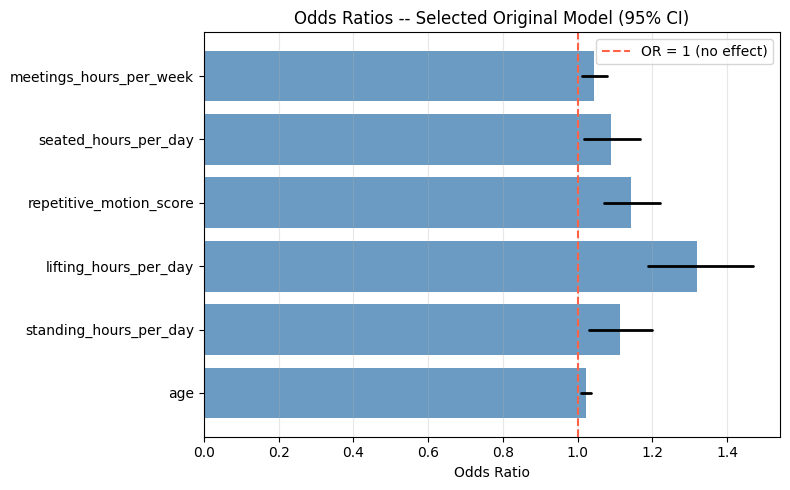

In [ ]:
# Original vars Logistic

# Full model 
X_orig_full = sm.add_constant(X_w)
logit_full   = sm.Logit(y_w, X_orig_full).fit(disp=0)
print(f"\n{'='*60}")
print("LOGISTIC REGRESSION , Full model (9 original features):")
print(logit_full.summary2())

# Select significant predictors 
sig_feats = [v for v in logit_full.pvalues.index if v != 'const' and logit_full.pvalues[v] < 0.05]
print(f"\nSignificant predictors (p < 0.05): {sig_feats}")

# Refit
X_orig_sel = sm.add_constant(X_w[sig_feats])
logit_sel   = sm.Logit(y_w, X_orig_sel).fit(disp=0)
print(f"\nLOGISTIC REGRESSION -- Selected model ({len(sig_feats)} features):")
print(logit_sel.summary2())

# Odds ratios + 95% CI for selected model
or_sel    = np.exp(logit_sel.params).drop('const')
or_ci_sel = np.exp(logit_sel.conf_int()).drop('const')
print("\nOdds Ratios (selected model):")
for feat in or_sel.index:
    print(f"  {feat}: OR={or_sel[feat]:.4f}  [{or_ci_sel.loc[feat,0]:.4f}, {or_ci_sel.loc[feat,1]:.4f}]")

# Odds ratio plot 
fig, ax = plt.subplots(figsize=(8, 5))
y_pos = range(len(or_sel))
ax.barh(list(y_pos), or_sel.values, color='steelblue', alpha=0.8)
for i, feat in enumerate(or_sel.index):
    ax.plot([or_ci_sel.loc[feat, 0], or_ci_sel.loc[feat, 1]], [i, i],
            color='black', lw=2, solid_capstyle='round')
ax.axvline(x=1, color='tomato', ls='--', lw=1.5, label='OR = 1 (no effect)')
ax.set_yticks(list(y_pos))
ax.set_yticklabels(or_sel.index)
ax.set_xlabel('Odds Ratio')
ax.set_title('Odds Ratios -- Selected Original Model (95% CI)')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### Logistic Regression with PCA Variables

Using the 3 retained principal components as predictors, all three are significant:

- PC1 (Physical Labour): OR = 1.608 [1.452, 1.780], p < 0.001
- PC2 (Desk Work): OR = 1.187 [1.070, 1.318], p = 0.001
- PC3 (Age/Seniority): OR = 1.173 [1.031, 1.334], p = 0.015

Pseudo-R2 = 0.076, AIC = 1321.32, 4 parameters (3 PCs + intercept).

Interpreting the coefficients:

- PC1 (OR = 1.61): a one-standard-deviation increase in PC1 — moving toward a more physically demanding job profile — is associated with a 61% increase in the odds of chronic pain. This is the dominant risk factor, and the large OR reflects the combined effect of four correlated physical-work variables compressed into one dimension.
- PC2 (OR = 1.19): workers who score higher on the desk-work dimension (more computer time, more meetings, higher income) have 19% higher odds of chronic pain per SD increase. This likely reflects musculoskeletal strain from prolonged static postures and sedentary work.
- PC3 (OR = 1.17): older, more senior workers have 17% higher odds of chronic pain per SD increase. Age is an independent risk factor for musculoskeletal conditions regardless of job type.

In [ ]:

# PCA Logistic regression

X_pca_3 = sm.add_constant(pc_named)
logit_pca = sm.Logit(y_w, X_pca_3).fit(disp=0)
print(f"\n{'='*60}")
print("LOGISTIC REGRESSION -- PCA model (3 retained PCs):")
print(logit_pca.summary2())

or_pca    = np.exp(logit_pca.params).drop('const')
or_ci_pca = np.exp(logit_pca.conf_int()).drop('const')
print("\nOdds Ratios (PCA model):")
for feat in or_pca.index:
    print(f"  {feat}: OR={or_pca[feat]:.4f}  [{or_ci_pca.loc[feat,0]:.4f}, {or_ci_pca.loc[feat,1]:.4f}]")

# Odds ratio plot -- PCA model
fig, ax = plt.subplots(figsize=(7, 4))
y_pos = range(len(or_pca))
ax.barh(list(y_pos), or_pca.values, color='darkorange', alpha=0.8)
for i, feat in enumerate(or_pca.index):
    ax.plot([or_ci_pca.loc[feat, 0], or_ci_pca.loc[feat, 1]], [i, i],
            color='black', lw=2, solid_capstyle='round')
ax.axvline(x=1, color='tomato', ls='--', lw=1.5, label='OR = 1 (no effect)')
ax.set_yticks(list(y_pos))
ax.set_yticklabels(or_pca.index)
ax.set_xlabel('Odds Ratio')
ax.set_title('Odds Ratios -- PCA Model (3 PCs, 95% CI)')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### Model Comparison

Comparing the three logistic regression models:

- Full original model (9 features): 10 parameters, log-likelihood = -651.81, AIC = 1323.62, BIC = 1374.52, Pseudo R2 = 0.083
- Selected original model (6 features): 7 parameters, log-likelihood = -654.35, AIC = 1322.70, BIC = 1358.33, Pseudo R2 = 0.079
- PCA model (3 components): 4 parameters, log-likelihood = -656.66, AIC = 1321.32, BIC = 1341.68, Pseudo R2 = 0.076

A few observations:

- The PCA model uses only 4 parameters compared to 7 (selected) or 10 (full)(parsimony win)



- Pseudo-R2: the full model has the highest (0.083), but all three are in a narrow range . None of the models explain a large part of the variance

- Interpretability: 
    - The original model will always be easier to interpret, since each variable describe some specific action. While the PCs are grouped variables that can sound more 'abstract' in a way. (e.g. actionable steps to reduce chronic pain are easier to identify in the original model)

Overall, the PCA model is preferable for  parsimony (best AIC, fewest parameters), while the selected original model is preferable for interpretability and inference (altough the multi collinearity is there)

In [ ]:
# Model comparison 


comparison_df = pd.DataFrame({
    'Model':        ['Full original (9)', 'Selected original (6)', 'PCA (3 PCs)'],
    'N Parameters': [int(logit_full.df_model) + 1,
                     int(logit_sel.df_model)  + 1,
                     int(logit_pca.df_model)  + 1],
    'Log-Lik':      [round(logit_full.llf, 2), round(logit_sel.llf, 2), round(logit_pca.llf, 2)],
    'AIC':          [round(logit_full.aic, 2), round(logit_sel.aic, 2), round(logit_pca.aic, 2)],
    'BIC':          [round(logit_full.bic, 2), round(logit_sel.bic, 2), round(logit_pca.bic, 2)],
    'Pseudo R²':    [round(logit_full.prsquared, 4),
                     round(logit_sel.prsquared, 4),
                     round(logit_pca.prsquared, 4)],
})
print(f"\n{'='*60}")
print("MODEL COMPARISON:")
print(comparison_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Logistic Regression Model Comparison', fontsize=13)

models     = comparison_df['Model'].tolist()
aic_vals   = comparison_df['AIC'].tolist()
pr2_vals   = comparison_df['Pseudo R²'].tolist()

axes[0].bar(models, aic_vals, color=['steelblue', 'steelblue', 'darkorange'], alpha=0.85)
axes[0].set_ylabel('AIC')
axes[0].set_title('AIC (lower = better)')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim(min(aic_vals) - 5, max(aic_vals) + 5)
for i, v in enumerate(aic_vals):
    axes[0].text(i, v + 0.3, f'{v:.1f}', ha='center', fontsize=9)

axes[1].bar(models, pr2_vals, color=['steelblue', 'steelblue', 'darkorange'], alpha=0.85)
axes[1].set_ylabel("McFadden's Pseudo R²")
axes[1].set_title("Pseudo R² (higher = better)")
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim(0, max(pr2_vals) + 0.01)
for i, v in enumerate(pr2_vals):
    axes[1].text(i, v + 0.0005, f'{v:.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## Q3. Reflection Questions

### Question 1: Why can PCs be predictive of chronic pain if PCA ignored the target variable?


Since PCs are 'grouped' by direction and variance, it does not need to 'look at' the target variable (the results) to group them, given that the original variables explain (are predictive) of chronic pain, then PCA would group them and these PCs would 'be passed along' this predictive association.

---

### Question 2: Is PCA guaranteed to improve predictive performance?

Not really, since PCA works on the variables that already exist, it basically 'reshuffles' them. If you input low 'variance explaining' variables, then the PCs won't be good as predictors. You will get bad predictive power. 
Also, since it's unsupervised, (it doesnt look at the target) it's more likely to discard variables that have at least some information/relationship with the target when compared to other methods. 

---

### Question 3: Feature Selection vs Feature Extraction (PCA)

Feature selection and feature extraction are both dimensionality reduction strategies, but they operate differently:

- Feature selection keeps a subset of the original variables (unchanged). The output variables still have their original meaning. For example, keeping only lifting hours and age means we can directly interpret each coefficient.

- Feature extraction  creates  new 'synthetic' variables which are just linear combinations of all original variables. The output doesn't correspond to any single measured variable (i.e. it is separated in PCs)

The key conceptual difference is that feature selection preserves the original variable space (choosing what to keep and what to discard), while feature extraction creates a new lower-dimensional representation (transforming all variables into derived components).

 In the original selected logistic regression model, we can directly say "each extra hour of lifting increases the log-odds by xyz ". With PCA, the coefficient for PC1 describes the effect of an the composiite, and we should look at the loadings to 'decompose it' 

QUESTION 2 APPENDED: